In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import sys
sys.path.insert(0, "/zhome/71/c/146676/texture_tomography/maptools")
import maptools
import os

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from multiprocessing import Pool
import pickle
import h5py
from datetime import datetime

maptools.job.info()
maptools.plot.dark()
!which python

import time
import numba
import ImageD11.columnfile
import ImageD11.sinograms.dataset
import ImageD11.sinograms.geometry as geometry
import ImageD11.sinograms.point_by_point
import ImageD11.sinograms.point_by_point as pbp
from ImageD11.nbGui import nb_utils as utils

hostname: n-62-11-21
SLURM_JOB_ID: None
SLURM_JOB_NODELIST: None
NPROCS: 24
Memory available: 800.120942592 GB
~/miniconda3/envs/textom/bin/python


In [7]:
root = "/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/al1050_15pct_center_slice"
filetag = "medium_pks_18M_2026_0924_134307"
pbp_map_path = os.path.join(root, filetag + "_pbpmap.h5")
dset_path = os.path.join(root, filetag + "_dummy_dset.h5")
colf_path = os.path.join(root, filetag + "_colf.h5")
y0 = maptools.constants.ROTATION_AXIS_DTY_SHIFT
# assert os.path.isfile(pbp_map_path)
# assert os.path.isfile(dset_path)
# assert os.path.isfile(colf_path)

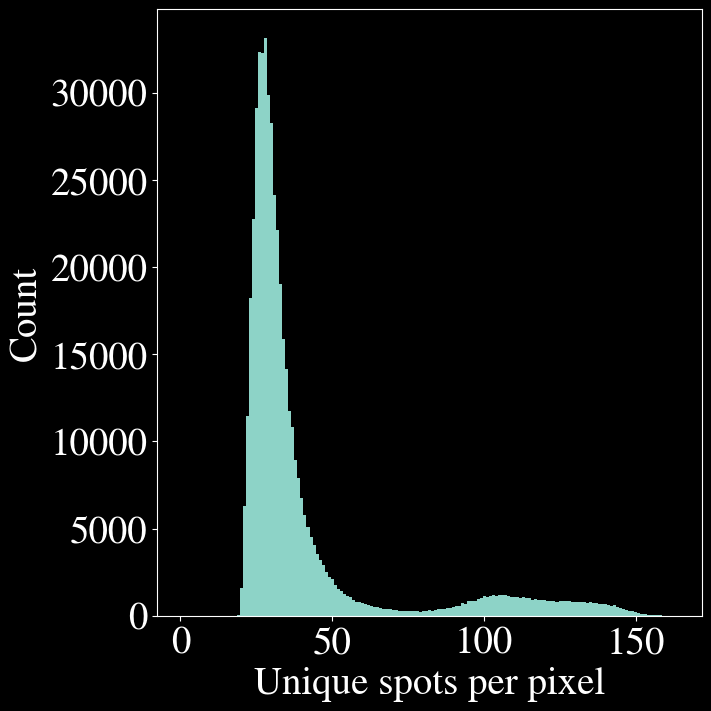

In [8]:
colf = ImageD11.columnfile.colfile_from_hdf(colf_path)
pbpmap = pbp.PBPMap(pbp_map_path)
dset = maptools.dummy.load_dset(dset_path)
pbpmap.plot_nuniq_hist()

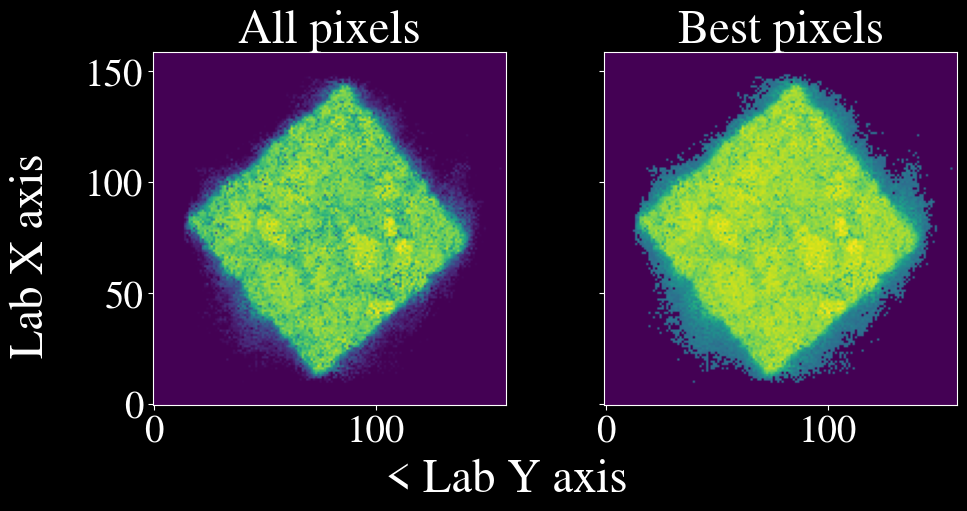

In [9]:
pbpmap.choose_best(minpeaks=55)
pbpmap.plot_best(minpeaks=55)

In [10]:
dset.refmapfile = pbp_map_path  # pbp map input
dset.refpeaksfile = os.path.join(
    root, "icolfile_refine_" + filetag + ".h5"
)  # icolf for refinement
dset.refoutfile = os.path.join(
    root, "pbpmap_refine_" + filetag + ".h5"
)  # refined pbp map output
dset.refmanfile = os.path.join(root, "pbprefiner_" + filetag + ".h5")  # myself as an H5

hkl_tol = 0.05  # only peaks that bit within this tolerance in reciprocal space to an integer h,k,l point are considered assigned to grain
ds_tol = 0.01  # Deviation from predicted theoretical ring value beyond which the peak is discared. In units of inverse angstrom i.e (1 / d)-tolerance where d is the lattice d-spacing
eta_wedge_in_degrees = 6  # Peaks close to eta=0 and eta=180 stay in diffraction all the time in omega, these are not good peaks to use.

etacut = np.sin(np.radians(np.abs(eta_wedge_in_degrees)))

refiner = pbp.PBPRefine(
    dset,
    phase_name=None,
    hkl_tol_origins=hkl_tol + 0.02,
    hkl_tol_refine=hkl_tol,
    hkl_tol_refine_merged=hkl_tol,
    ds_tol=ds_tol,
    etacut=etacut,
    ifrac=None,
    forref=None,
    y0=y0,
    min_grain_npks=30,
)

In [11]:
refiner.setmap(pbpmap)

In [12]:
refiner.setpeaks(colf, del_existing=False, prompt_del=True)

0 0.4272 (1, 1, 1) 8 385562 used, sum_intensity> 2124.9668874172185
1 0.4933 (0, 2, 0) 6 255330 used, sum_intensity> 1639.3245033112582
2 0.6977 (2, 2, 0) 12 807593 used, sum_intensity> 538.1258278145696
3 0.8181 (3, 1, 1) 24 1530143 used, sum_intensity> 442.1324503311258
4 0.8545 (2, 2, 2) 8 575757 used, sum_intensity> 312.5960264900662
5 0.9867 (4, 0, 0) 6 518512 used, sum_intensity> 180.98013245033113
6 1.0752 (1, 3, 3) 24 1427002 used, sum_intensity> 178.90728476821192
7 1.1031 (2, 0, 4) 24 1537984 used, sum_intensity> 155.60927152317882
8 1.2084 (2, 2, 4) 24 1421679 used, sum_intensity> 92.44370860927152
9 1.2817 (3, 3, 3) 32 258652 used, sum_intensity> 341.74834437086093
10 1.3954 (4, 4, 0) 12 87919 used, sum_intensity> 176.5430463576159
11 1.4593 (3, 5, 1) 48 280452 used, sum_intensity> 141.4569536423841
12 1.4800 (2, 4, 4) 30 206555 used, sum_intensity> 51.37748344370861
13 1.5601 (2, 6, 0) 24 40865 used, sum_intensity> 105.23178807947019
14 1.6175 (5, 3, 3) 24 18976 used, sum_

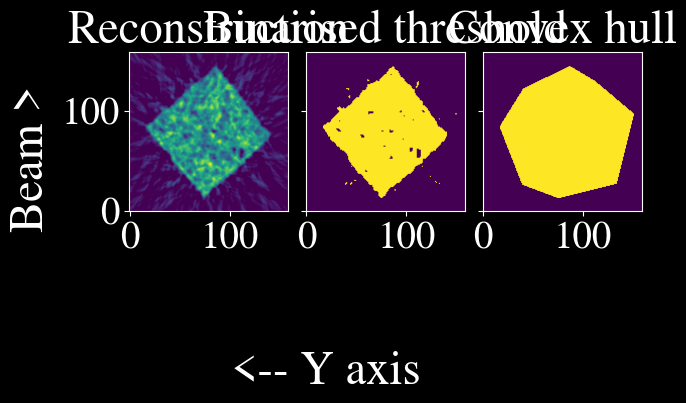

In [13]:
refiner.setmask(manual_threshold=0.15, doplot=True, use_icolf=True)

In [14]:
refiner.setsingle(pbpmap, method="best", minpeaks=50)

In [15]:
refiner.get_origins(guess_speed=True, guess_npks=10000, save_peaks_after=True)

Getting gvecs...
Running test function twice for the first 10000 peaks to guess speed...
This is because we get speed advantages with peaks on consecutive frames
First time to trigger NJIT
Now we time
I estimate roughly 4.90629272347191 seconds for all peaks in self.icolf
That's 0.0013628590898533083 hours
Lexsort...
Running numba computation on 23 threads, may take a while!
xpos_refined column added to self.icolf
Saving self.icolf to disk with new column


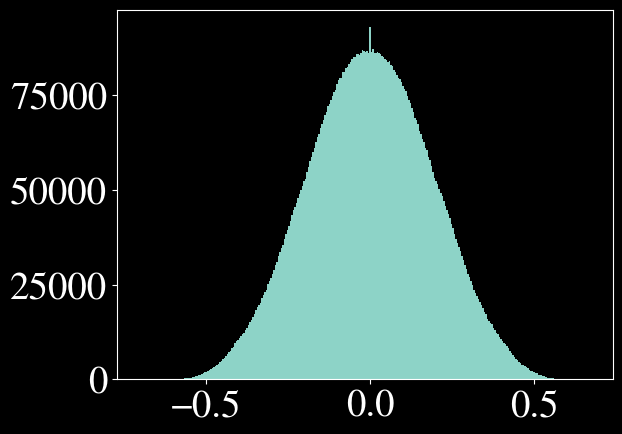

In [16]:
plt.figure()
plt.hist(refiner.icolf.xpos_refined, bins=300)
plt.show()

In [17]:
refiner.run_refine(
    points_step_space=None,
    npoints=None,
    output_filename="tmp_" + filetag,
    use_cluster=False,
    pythonpath=None,
)

Launching Numba parallel refinement on 23 threads
Saving refined map to disk


In [18]:
refiner.refinedmap_filename

'tmp_medium_pks_18M_2026_0924_134307'

Reading your columnfile in hdf format


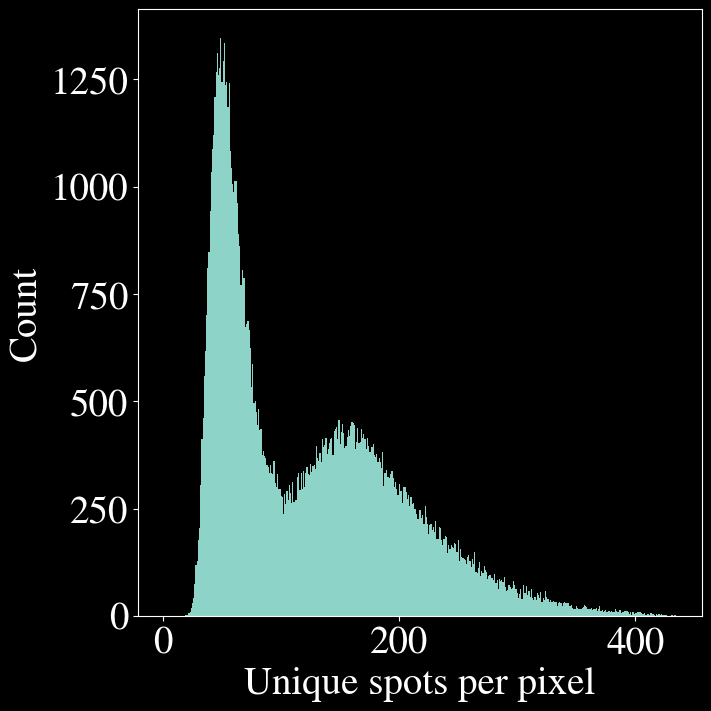

In [19]:
refined_pbpmap = pbp.PBPMap(refiner.refinedmap_filename)
refined_pbpmap.plot_nuniq_hist()

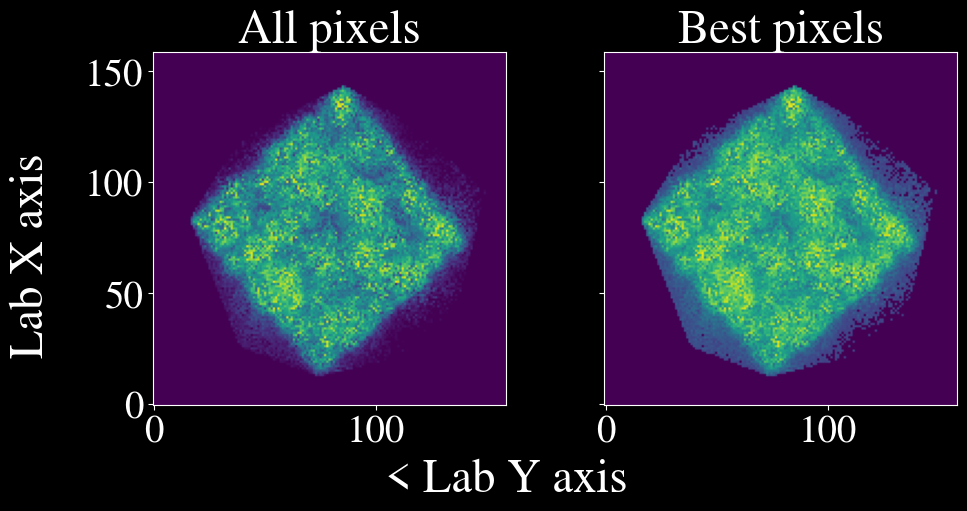

In [20]:
refined_pbpmap.choose_best(minpeaks=80)
refined_pbpmap.plot_best(minpeaks=80)

In [21]:
ucell = maptools.constants.UNITCELL

grains = []
for ubi in refined_pbpmap.best_ubi.reshape(-1, 3, 3):
    if not np.isnan(ubi).any():
        g = ImageD11.grain.grain(ubi)
        g.ref_unitcell = ucell
        grains.append(g)

m = ~np.isnan(refined_pbpmap.best_ubi[:, :, 0, 0])
from ImageD11.nbGui import nb_utils as utils

utils.get_rgbs_for_grains(grains)
gmap = np.empty(m.shape, dtype=object)
gmap[m] = grains

In [22]:
ubimap = refined_pbpmap.best_ubi
rgbmap = np.zeros((*m.shape, 3))
for i in range(ubimap.shape[0]):
    for j in range(ubimap.shape[1]):
        if ~np.isnan(ubimap[i, j]).any():
            rgbmap[i, j] = gmap[i, j].rgb_z

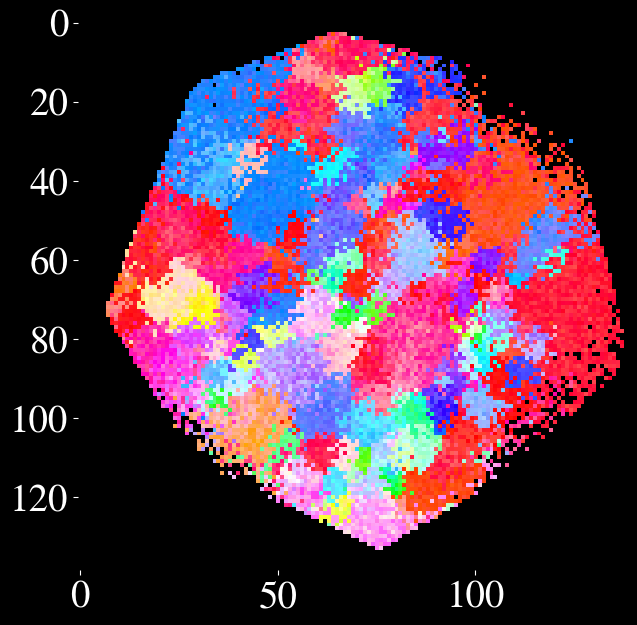

In [23]:
plt.style.use("dark_background")
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
from scipy.ndimage import gaussian_filter

s = refined_pbpmap.best_nuniq[:, :, None].astype(float)
s = gaussian_filter(s, 1)
s /= s.max()
s[s < 0.1] = 0
s[s > 0] = 1
for spine in ax.spines.values():
    spine.set_visible(False)
im = ax.imshow((rgbmap * s)[10:-10, 10:-10])
plt.tight_layout()
plt.show()

In [24]:
refined_pbpmap.writefile(dset.refoutfile)
dset.save()

In [25]:
dset.refoutfile.split("/")[-1][14:-3]

'medium_pks_18M_2026_0924_134307'